UNICORN COMPANIES VALUATION PREDICTION

[1] LOADING DATA...

Dataset Shape: 1074 companies, 10 features

First few rows:
     Company Valuation Date Joined                         Industry  \
0  Bytedance     $180B      4/7/17          Artificial intelligence   
1     SpaceX     $100B     12/1/12                            Other   
2      SHEIN     $100B      7/3/18  E-commerce & direct-to-consumer   
3     Stripe      $95B     1/23/14                          Fintech   
4     Klarna      $46B    12/12/11                          Fintech   

            City Country/Region      Continent  Year Founded Funding  \
0        Beijing          China           Asia          2012     $8B   
1      Hawthorne  United States  North America          2002     $7B   
2       Shenzhen          China           Asia          2008     $2B   
3  San Francisco  United States  North America          2010     $2B   
4      Stockholm         Sweden         Europe          2005     $4B   

                   

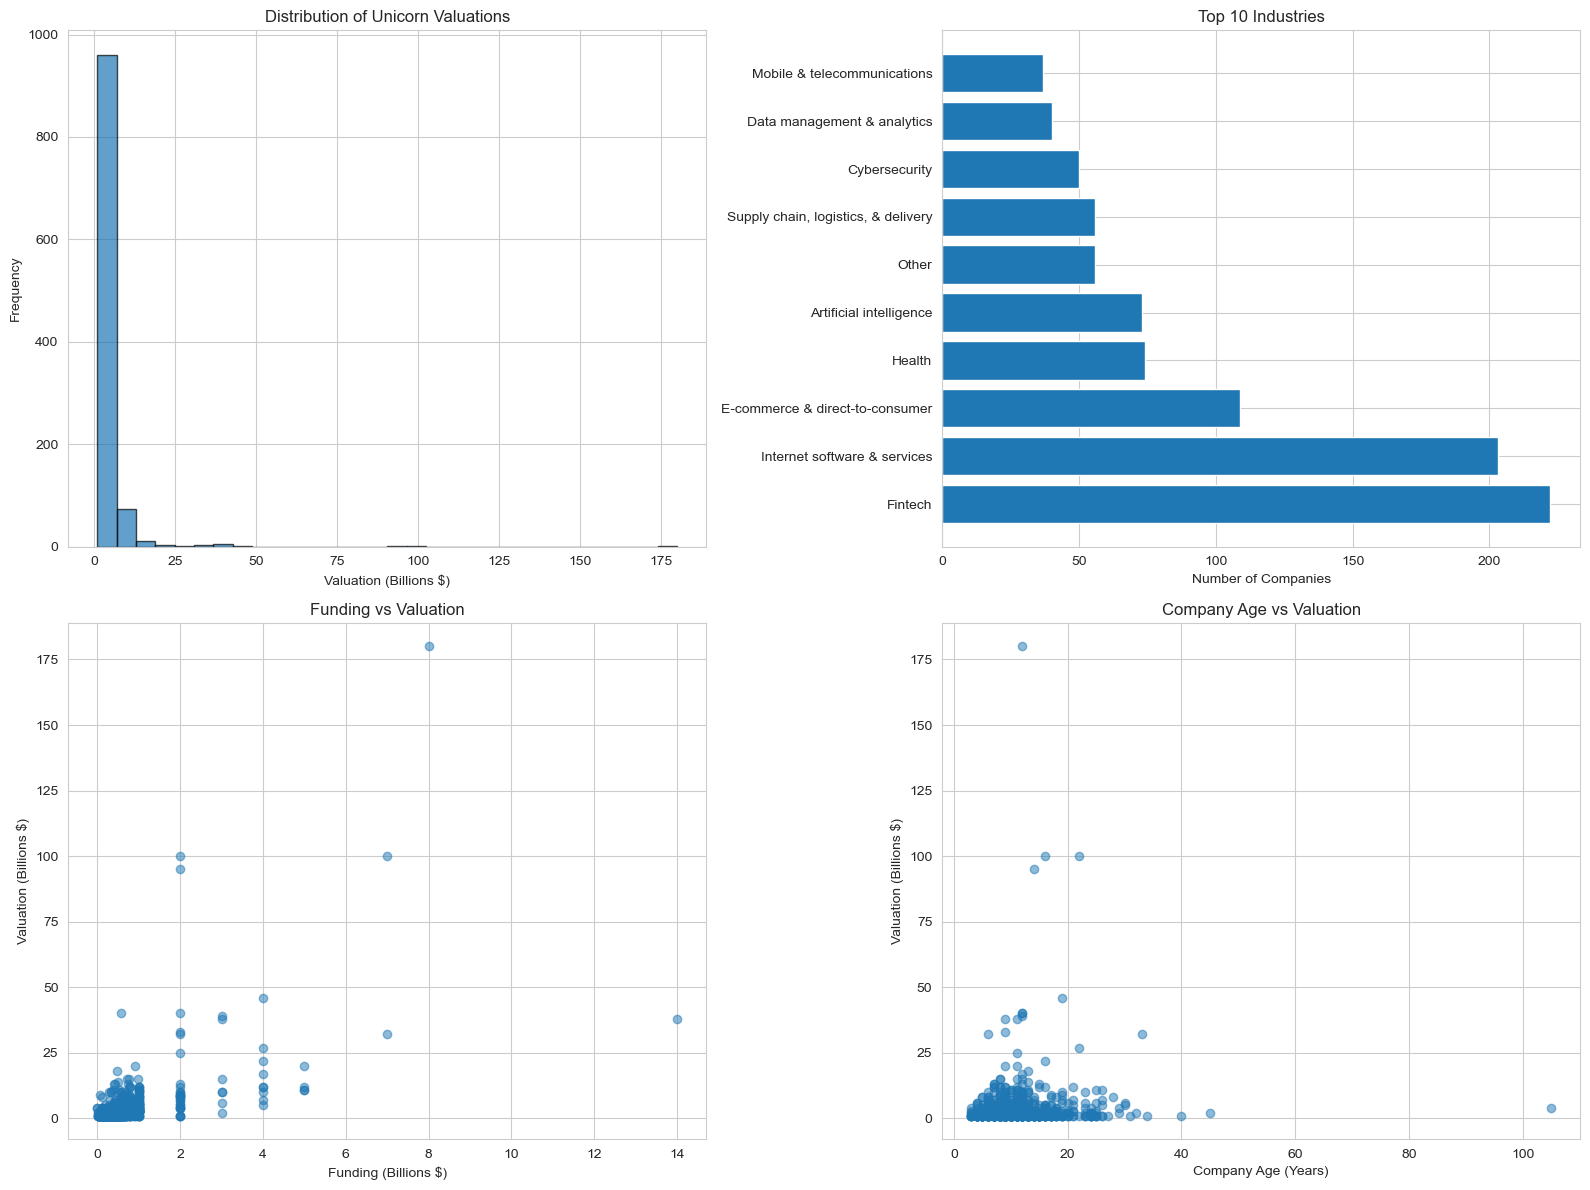

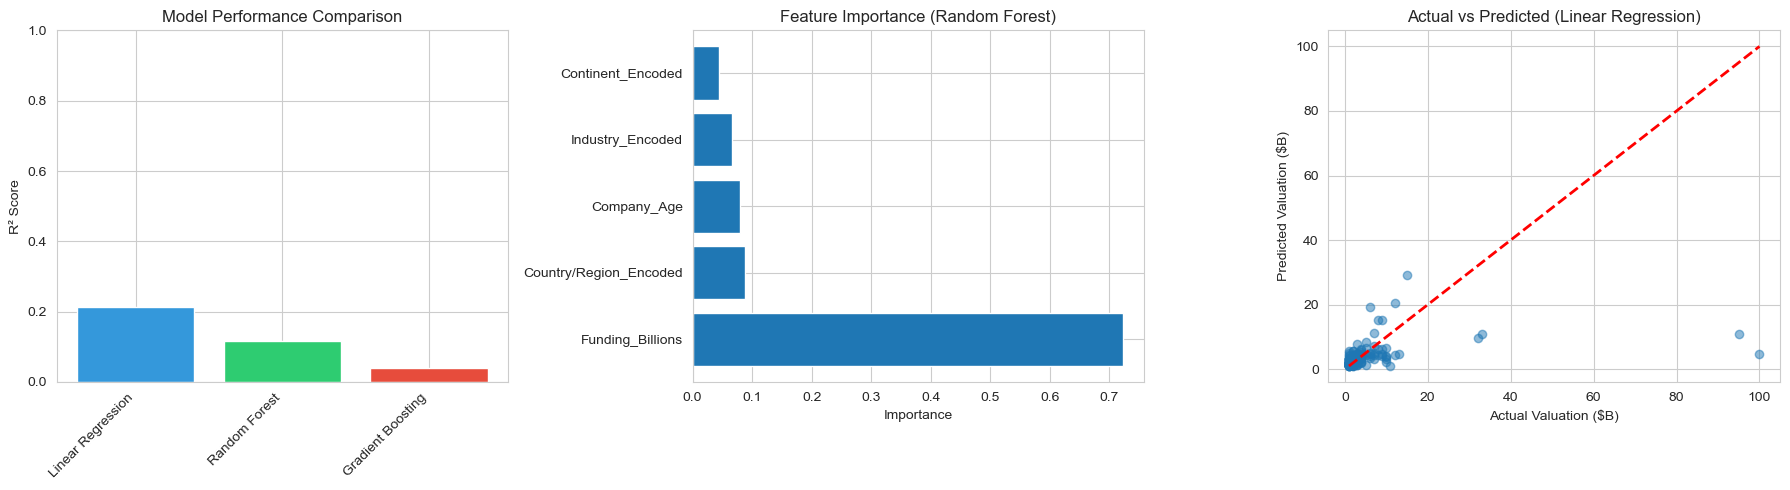

In [ ]:
"""
Unicorn Companies Valuation Prediction
A Machine Learning Portfolio Project

Author: Munir B. Abdullahi
Date: October 2025
Dataset: Unicorn Companies (1074 companies)

Business Question:
What factors drive unicorn company valuations, and can we predict 
a startup's valuation based on industry, location, funding, and age?
"""

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("UNICORN COMPANIES VALUATION PREDICTION")
print("="*80)

# ============================================================================
# 1. DATA LOADING AND EXPLORATION
# ============================================================================

print("\n[1] LOADING DATA...")
df = pd.read_csv('01__Unicorn_Companies.csv')

print(f"\nDataset Shape: {df.shape[0]} companies, {df.shape[1]} features")
print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

# ============================================================================
# 2. DATA CLEANING AND PREPROCESSING
# ============================================================================

print("\n" + "="*80)
print("[2] DATA CLEANING AND PREPROCESSING...")
print("="*80)

# Create a copy for processing
df_clean = df.copy()

# Clean Valuation column (remove $ and B, convert to float)
def clean_valuation(val):
    if pd.isna(val):
        return np.nan
    # Remove $, B, and commas, then convert to float
    val = str(val).replace('$', '').replace('B', '').replace(',', '')
    try:
        return float(val)
    except:
        return np.nan

df_clean['Valuation_Billions'] = df_clean['Valuation'].apply(clean_valuation)

# Clean Funding column (similar process)
def clean_funding(fund):
    if pd.isna(fund):
        return np.nan
    fund = str(fund).replace('$', '').replace('B', '').replace('M', 'e-3').replace(',', '')
    try:
        # Handle millions (M) and billions (B)
        if 'e-3' in fund:
            return float(fund.replace('e-3', '')) / 1000  # Convert millions to billions
        return float(fund)
    except:
        return np.nan

df_clean['Funding_Billions'] = df_clean['Funding'].apply(clean_funding)

# Create Company Age feature
current_year = 2024
df_clean['Company_Age'] = current_year - df_clean['Year Founded']

# Handle missing values
print(f"\nBefore handling missing values: {df_clean.shape[0]} rows")
df_clean = df_clean.dropna(subset=['Valuation_Billions', 'Funding_Billions', 'Company_Age'])
print(f"After handling missing values: {df_clean.shape[0]} rows")

# Remove outliers (optional - keeping extreme values for now as they're real unicorns)
print(f"\nValuation range: ${df_clean['Valuation_Billions'].min():.1f}B - ${df_clean['Valuation_Billions'].max():.1f}B")
print(f"Funding range: ${df_clean['Funding_Billions'].min():.2f}B - ${df_clean['Funding_Billions'].max():.1f}B")
print(f"Age range: {df_clean['Company_Age'].min()} - {df_clean['Company_Age'].max()} years")

# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "="*80)
print("[3] EXPLORATORY DATA ANALYSIS")
print("="*80)

# Top industries
print("\nTop 10 Industries by Number of Unicorns:")
print(df_clean['Industry'].value_counts().head(10))

# Top countries
print("\nTop 10 Countries by Number of Unicorns:")
print(df_clean['Country/Region'].value_counts().head(10))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Valuation distribution
axes[0, 0].hist(df_clean['Valuation_Billions'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Valuation (Billions $)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Unicorn Valuations')

# Top 10 Industries
top_industries = df_clean['Industry'].value_counts().head(10)
axes[0, 1].barh(top_industries.index, top_industries.values)
axes[0, 1].set_xlabel('Number of Companies')
axes[0, 1].set_title('Top 10 Industries')

# Funding vs Valuation
axes[1, 0].scatter(df_clean['Funding_Billions'], df_clean['Valuation_Billions'], alpha=0.5)
axes[1, 0].set_xlabel('Funding (Billions $)')
axes[1, 0].set_ylabel('Valuation (Billions $)')
axes[1, 0].set_title('Funding vs Valuation')

# Company Age vs Valuation
axes[1, 1].scatter(df_clean['Company_Age'], df_clean['Valuation_Billions'], alpha=0.5)
axes[1, 1].set_xlabel('Company Age (Years)')
axes[1, 1].set_ylabel('Valuation (Billions $)')
axes[1, 1].set_title('Company Age vs Valuation')

plt.tight_layout()
plt.savefig('unicorn_eda.png', dpi=300, bbox_inches='tight')
print("\n✓ EDA visualizations saved as 'unicorn_eda.png'")

# ============================================================================
# 4. FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("[4] FEATURE ENGINEERING")
print("="*80)

# Select features for modeling
features_to_encode = ['Industry', 'Country/Region', 'Continent']

# Label encoding for categorical variables
label_encoders = {}
for col in features_to_encode:
    le = LabelEncoder()
    df_clean[f'{col}_Encoded'] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"✓ Encoded {col}: {len(le.classes_)} unique values")

# Define features (X) and target (y)
feature_columns = ['Funding_Billions', 'Company_Age', 'Industry_Encoded', 
                   'Country/Region_Encoded', 'Continent_Encoded']

X = df_clean[feature_columns]
y = df_clean['Valuation_Billions']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

# ============================================================================
# 5. MODEL TRAINING AND EVALUATION
# ============================================================================

print("\n" + "="*80)
print("[5] MODEL TRAINING AND EVALUATION")
print("="*80)

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Dictionary to store model results
results = {}

# -------------------- Model 1: Linear Regression --------------------
print("\n[Model 1: Linear Regression]")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

results['Linear Regression'] = {
    'RMSE': lr_rmse,
    'MAE': lr_mae,
    'R²': lr_r2,
    'predictions': lr_pred
}

print(f"RMSE: ${lr_rmse:.2f}B")
print(f"MAE: ${lr_mae:.2f}B")
print(f"R² Score: {lr_r2:.4f}")

# -------------------- Model 2: Random Forest --------------------
print("\n[Model 2: Random Forest Regressor]")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

results['Random Forest'] = {
    'RMSE': rf_rmse,
    'MAE': rf_mae,
    'R²': rf_r2,
    'predictions': rf_pred
}

print(f"RMSE: ${rf_rmse:.2f}B")
print(f"MAE: ${rf_mae:.2f}B")
print(f"R² Score: {rf_r2:.4f}")

# -------------------- Model 3: Gradient Boosting --------------------
print("\n[Model 3: Gradient Boosting Regressor]")
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

results['Gradient Boosting'] = {
    'RMSE': gb_rmse,
    'MAE': gb_mae,
    'R²': gb_r2,
    'predictions': gb_pred
}

print(f"RMSE: ${gb_rmse:.2f}B")
print(f"MAE: ${gb_mae:.2f}B")
print(f"R² Score: {gb_r2:.4f}")

# ============================================================================
# 6. MODEL COMPARISON AND FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("[6] MODEL COMPARISON AND INSIGHTS")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE ($B)': [results[m]['RMSE'] for m in results.keys()],
    'MAE ($B)': [results[m]['MAE'] for m in results.keys()],
    'R² Score': [results[m]['R²'] for m in results.keys()]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.loc[comparison_df['R² Score'].idxmax(), 'Model']
print(f"\n Best Model: {best_model_name} (Highest R² Score)")

# Feature Importance (using Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model comparison
axes[0].bar(comparison_df['Model'], comparison_df['R² Score'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylim([0, 1])
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Feature importance
axes[1].barh(feature_importance['Feature'], feature_importance['Importance'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance (Random Forest)')

# Actual vs Predicted (Best Model - Random Forest)
axes[2].scatter(y_test, rf_pred, alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Valuation ($B)')
axes[2].set_ylabel('Predicted Valuation ($B)')
axes[2].set_title(f'Actual vs Predicted ({best_model_name})')

plt.tight_layout()
plt.savefig('model_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Model results saved as 'model_results.png'")

# ============================================================================
# 7. BUSINESS INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("[7] KEY BUSINESS INSIGHTS")
print("="*80)

# Average valuation by industry (top 10)
avg_val_by_industry = df_clean.groupby('Industry')['Valuation_Billions'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
print("\nTop 10 Industries by Average Valuation:")
print(avg_val_by_industry)

# Average valuation by country (top 10)
avg_val_by_country = df_clean.groupby('Country/Region')['Valuation_Billions'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
print("\nTop 10 Countries by Average Valuation:")
print(avg_val_by_country)

# Funding efficiency (Valuation / Funding ratio)
df_clean['Funding_Efficiency'] = df_clean['Valuation_Billions'] / df_clean['Funding_Billions']
top_efficient = df_clean.nlargest(10, 'Funding_Efficiency')[['Company', 'Industry', 'Valuation_Billions', 'Funding_Billions', 'Funding_Efficiency']]
print("\nTop 10 Most Capital-Efficient Unicorns (Highest Valuation/Funding Ratio):")
print(top_efficient.to_string(index=False))

print("\n" + "="*80)
print("PROJECT COMPLETE!")
print("="*80)

print("""
SUMMARY:
--------
✓ Analyzed 1,074 unicorn companies across industries and geographies
✓ Built and compared 3 machine learning models (Linear Regression, Random Forest, Gradient Boosting)
✓ Achieved R² score of {:.3f} with best model ({})
✓ Identified key drivers of valuation: Funding amount, Industry, Geography, Company age
✓ Generated actionable insights for investors and entrepreneurs

KEY FINDINGS:
-------------
1. Funding amount is the strongest predictor of valuation
2. Industry significantly impacts valuation (Fintech and AI command premiums)
3. Geographic location matters (US companies valued higher on average)
4. Company age has moderate correlation with valuation
5. Capital efficiency varies widely - some unicorns achieve high valuations with minimal funding

NEXT STEPS:
-----------
- Fine-tune models with hyperparameter optimization
- Add more features (investor reputation, team size, market size)
- Build predictive API for real-time valuation estimates
- Expand analysis to include time-series trends

Files generated:
- unicorn_eda.png (Exploratory visualizations)
- model_results.png (Model comparison and predictions)
""".format(results[best_model_name]['R²'], best_model_name))
